# **EDA WITH IMPORTS AND READ FILES**

In [89]:
!pip install -q mlflow

In [90]:
from pathlib import Path
import os
from google.colab import drive

drive.mount('/content/drive')
IN_COLAB = True
DATA_DIR = Path("/content/drive/MyDrive/fite-classification-challenge")


train_path = DATA_DIR / "train_data.csv"
test_path = DATA_DIR / "test_data.csv"
sample_path = DATA_DIR / "sample_submission.csv"

# train_path ="train_data.csv"
# test_path = "test_data.csv"
# sample_path ="sample_submission.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [91]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import mlflow
import mlflow.sklearn

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)

In [92]:
# if not train_path.exists():
#     raise FileNotFoundError(f"train_data.csv not found at: {train_path}")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
# if test_path.exists() else None
sample_submission = pd.read_csv(sample_path)
# if sample_path.exists() else None

print("Train shape:", train.shape)
print("Test shape :", None if test is None else test.shape)
print("Sample submission shape:", None if sample_submission is None else sample_submission.shape)

Train shape: (3200, 23)
Test shape : (3200, 22)
Sample submission shape: (3200, 2)


In [93]:
TARGET_COL = "target"
ID_COL = "ID"
feature_cols = [c for c in train.columns if c not in [ID_COL, TARGET_COL]]

print("Columns:")
print(list(train.columns))
print("\nNumber of features:", len(feature_cols))
print("Feature columns:", feature_cols)

if test is not None:
    missing_in_test = set(feature_cols) - set(test.columns)
    extra_in_test = set(test.columns) - set(feature_cols) - {ID_COL}
    print("\nMissing features in test:", missing_in_test)
    print("Extra columns in test:", extra_in_test)

Columns:
['ID', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'target']

Number of features: 21
Feature columns: ['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21']

Missing features in test: set()
Extra columns in test: set()


In [94]:
display(train.head(10))
print("\nInfo:")
train.info()

,ID,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,target
0,1,0.38,0.0160,0,0,0,0,0,0,0.10800,0.00088,0,0,0,0.12700,0,1,0,0,0,0.085,0,class3
1,2,0.37,0.0250,0,0,0,0,0,0,0.08400,0.00510,0,0,0,0.08000,0,0,0,0,0,0.104,0,class3
2,3,0.57,0.0220,0,0,0,0,0,0,0.11118,0.00189,0,0,0,0.11207,0,0,0,0,0,0.099,0,class3
3,4,0.54,0.0206,0,1,0,0,0,0,0.10100,0.00020,0,1,0,0.15800,0,0,0,0,0,0.064,0,class3
4,5,0.42,0.0208,0,0,0,0,0,0,0.12300,0.00720,0,0,0,0.10400,0,0,0,0,0,0.116,0,class2
5,6,0.57,0.0300,0,0,0,0,0,0,0.10600,0.00180,0,0,0,0.09600,0,0,0,0,0,0.112,0,class3
6,7,0.64,0.0100,0,0,0,0,0,0,0.10100,0.00009,0,0,0,0.12300,0,0,0,0,0,0.082,0,class3
7,8,0.66,0.0160,0,0,0,0,0,0,0.12600,0.00320,0,0,0,0.12300,0,0,0,0,0,0.102,0,class3
8,9,0.34,0.0200,0,0,0,0,0,0,0.09500,0.00780,1,0,0,0.09600,0,0,0,0,0,0.099,0,class2
9,10,0.28,0.0230,0,0,0,0,0,0,0.04200,0.03500,1,0,0,0.04100,0,0,0,0,0,0.101,0,class1



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      3200 non-null   int64  
 1   f1      3200 non-null   float64
 2   f2      3200 non-null   float64
 3   f3      3200 non-null   int64  
 4   f4      3200 non-null   int64  
 5   f5      3200 non-null   int64  
 6   f6      3200 non-null   int64  
 7   f7      3200 non-null   int64  
 8   f8      3200 non-null   int64  
 9   f9      3200 non-null   float64
 10  f10     3200 non-null   float64
 11  f11     3200 non-null   int64  
 12  f12     3200 non-null   int64  
 13  f13     3200 non-null   int64  
 14  f14     3200 non-null   float64
 15  f15     3200 non-null   int64  
 16  f16     3200 non-null   int64  
 17  f17     3200 non-null   int64  
 18  f18     3200 non-null   int64  
 19  f19     3200 non-null   int64  
 20  f20     3200 non-null   float64
 21  f21     3200 non-null   int64 

,count,percent
target,,
class3,2916,91.12
class2,191,5.97
class1,93,2.91


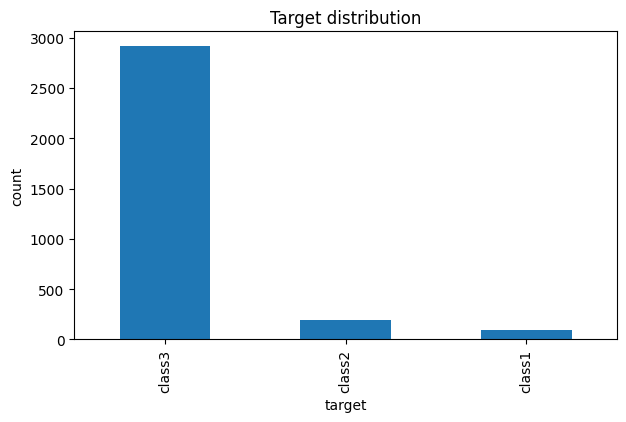

Majority class ratio: 0.9113


In [95]:
target_counts = train[TARGET_COL].value_counts()
target_percent = train[TARGET_COL].value_counts(normalize=True).mul(100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_percent
})
display(target_summary)

plt.figure(figsize=(7, 4))
target_counts.plot(kind="bar")
plt.title("Target distribution")
plt.xlabel("target")
plt.ylabel("count")
plt.show()

majority_ratio = target_counts.max() / target_counts.sum()
print(f"Majority class ratio: {majority_ratio:.4f}")

In [96]:
missing_train = train[feature_cols].isna().sum().sort_values(ascending=False)
missing_percent = (missing_train / len(train) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing_train, "missing_percent": missing_percent})

display(missing_table[missing_table["missing_count"] > 0])
print("Total missing in train features:", int(missing_train.sum()))

if test is not None:
    missing_test = test[feature_cols].isna().sum().sort_values(ascending=False)
    missing_test_percent = (missing_test / len(test) * 100).round(2)
    missing_test_table = pd.DataFrame({"missing_count": missing_test, "missing_percent": missing_test_percent})
    print("\nTest missing values:")
    display(missing_test_table[missing_test_table["missing_count"] > 0])
    print("Total missing in test features:", int(missing_test.sum()))

,missing_count,missing_percent


Total missing in train features: 0

Test missing values:


,missing_count,missing_percent


Total missing in test features: 0


In [97]:
duplicated_ids = train[ID_COL].duplicated().sum()
full_duplicate_rows = train.duplicated().sum()
duplicate_feature_rows = train.duplicated(subset=feature_cols).sum()
duplicate_feature_target_rows = train.duplicated(subset=feature_cols + [TARGET_COL]).sum()

print("Number of rows:", len(train))
print("Unique IDs:", train[ID_COL].nunique())
print("Duplicated IDs:", duplicated_ids)
print("\nFull duplicate rows:", full_duplicate_rows)
print("Duplicate feature rows ignoring ID and target:", duplicate_feature_rows)
print("Duplicate feature+target rows ignoring ID:", duplicate_feature_target_rows)

feature_group_sizes = train.groupby(feature_cols, dropna=False).size().reset_index(name="group_size")
duplicate_groups = feature_group_sizes[feature_group_sizes["group_size"] > 1].sort_values("group_size", ascending=False)

print("\nNumber of duplicate feature groups:", len(duplicate_groups))
display(duplicate_groups.head(10))

target_per_feature_group = train.groupby(feature_cols, dropna=False)[TARGET_COL].nunique().reset_index(name="n_targets")
conflicting_groups = target_per_feature_group[target_per_feature_group["n_targets"] > 1]
print("Conflicting duplicate groups with more than one target:", len(conflicting_groups))

Number of rows: 3200
Unique IDs: 3200
Duplicated IDs: 0

Full duplicate rows: 0
Duplicate feature rows ignoring ID and target: 57
Duplicate feature+target rows ignoring ID: 57

Number of duplicate feature groups: 30


,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,group_size
344,0.26,0.0206,0,0,0,0,0,0,0.11118,0.00189,0,0,0,0.11207,0,0,0,0,0,0.099,0,6
626,0.33,0.0206,0,0,0,0,0,0,0.11118,0.00189,0,0,0,0.11207,0,0,0,0,0,0.099,0,5
589,0.32,0.0206,0,0,0,0,0,0,0.11118,0.00189,0,0,0,0.11207,0,0,0,0,0,0.099,0,4
479,0.29,0.0206,0,0,0,0,0,0,0.11118,0.00189,0,0,0,0.11207,0,0,0,0,0,0.099,0,4
1398,0.51,0.0206,0,0,0,0,0,0,0.11118,0.00189,0,0,0,0.11207,0,0,0,0,0,0.099,0,4
1000,0.41,0.0206,0,0,0,0,0,0,0.11118,0.00189,0,0,0,0.11207,0,0,0,0,0,0.099,0,4
1763,0.58,0.0206,0,0,0,0,0,0,0.11118,0.00189,0,0,0,0.11207,0,0,0,0,0,0.099,0,4
1709,0.57,0.0206,0,0,0,0,0,0,0.11118,0.00189,0,0,0,0.11207,0,0,0,0,0,0.099,0,4
2244,0.65,0.0206,0,0,0,0,0,0,0.11118,0.00189,0,0,0,0.11207,0,0,0,0,0,0.099,0,3
2189,0.64,0.0206,0,0,0,0,0,0,0.11118,0.00189,0,0,0,0.11207,0,0,0,0,0,0.099,0,3


Conflicting duplicate groups with more than one target: 0


In [98]:
train["feature_group_id"] = pd.util.hash_pandas_object(train[feature_cols], index=False).astype("int64")

group_counts = train["feature_group_id"].value_counts()
print("Number of unique feature groups:", train["feature_group_id"].nunique())
print("Rows belonging to duplicate groups:", int(group_counts[group_counts > 1].sum()))
print("Largest duplicate group size:", int(group_counts.max()))


Number of unique feature groups: 3143
Rows belonging to duplicate groups: 87
Largest duplicate group size: 6


In [99]:
if test is not None:
    print("Test rows:", len(test))
    print("Unique test IDs:", test[ID_COL].nunique())
    print("Duplicated test IDs:", test[ID_COL].duplicated().sum())

    test_full_duplicate_rows = test.duplicated().sum()
    test_duplicate_feature_rows = test.duplicated(subset=feature_cols).sum()

    print("\nFull duplicate rows in test:", test_full_duplicate_rows)
    print("Duplicate feature rows in test ignoring ID:", test_duplicate_feature_rows)

    test_group_sizes = (
        test.groupby(feature_cols, dropna=False)
        .size()
        .reset_index(name="group_size")
    )

    test_duplicate_groups = (
        test_group_sizes[test_group_sizes["group_size"] > 1]
        .sort_values("group_size", ascending=False)
    )

    print("Number of duplicate feature groups in test:", len(test_duplicate_groups))
    print("Rows belonging to duplicate feature groups in test:",
          int(test_duplicate_groups["group_size"].sum()) if len(test_duplicate_groups) else 0)

    display(test_duplicate_groups.head(20))

Test rows: 3200
Unique test IDs: 3200
Duplicated test IDs: 0

Full duplicate rows in test: 0
Duplicate feature rows in test ignoring ID: 7
Number of duplicate feature groups in test: 5
Rows belonging to duplicate feature groups in test: 12


,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,group_size
869,0.39,0.0201,0,0,0,0,0,0,0.11329,0.00232,0,0,0,0.11776,0,0,0,0,0,0.096,0,4
318,0.26,0.0201,0,0,0,0,0,0,0.11329,0.00232,0,0,0,0.11776,0,0,0,0,0,0.096,0,2
638,0.34,0.0201,0,0,0,0,0,0,0.11329,0.00232,0,0,0,0.11776,0,0,0,0,0,0.096,0,2
1359,0.50,0.0201,0,0,0,0,0,0,0.11329,0.00232,0,0,0,0.11776,0,0,0,0,0,0.096,0,2
1391,0.51,0.0201,0,0,0,0,0,0,0.11329,0.00232,0,0,0,0.11776,0,0,0,0,0,0.096,0,2


In [100]:
X_raw = train[feature_cols].copy()
y = train[TARGET_COL].copy()
if test is not None:
    train_keys = pd.util.hash_pandas_object(train[feature_cols], index=False).astype(str)
    test_keys = pd.util.hash_pandas_object(test[feature_cols], index=False).astype(str)

    train_key_target = (
        pd.DataFrame({"key": train_keys, TARGET_COL: y})
        .groupby("key")[TARGET_COL]
        .agg(n_targets="nunique", target_mode=lambda s: s.mode().iloc[0], train_count="size")
        .reset_index()
    )

    matched = pd.DataFrame({
        ID_COL: test[ID_COL],
        "key": test_keys
    }).merge(train_key_target, on="key", how="left")

    print("Test rows exactly matching at least one train feature row:",
          matched["target_mode"].notna().sum())

    print("Matched rows with conflicting train targets:",
          matched["n_targets"].gt(1).sum())

    display(matched[matched["target_mode"].notna()].head(20))

Test rows exactly matching at least one train feature row: 0
Matched rows with conflicting train targets: 0


,ID,key,n_targets,target_mode,train_count


In [101]:
X_raw = train[feature_cols].copy()
y = train[TARGET_COL].copy()

numeric_cols = X_raw.select_dtypes(include=np.number).columns.tolist()
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

binary_cols = []
continuous_cols = []
for col in numeric_cols:
    vals = set(X_raw[col].dropna().unique())
    if vals.issubset({0, 1}) and len(vals) <= 2:
        binary_cols.append(col)
    else:
        continuous_cols.append(col)

print("Numeric columns:", len(numeric_cols), numeric_cols)
print("Binary columns:", len(binary_cols), binary_cols)
print("Continuous columns:", len(continuous_cols), continuous_cols)
print("Categorical columns:", len(categorical_cols), categorical_cols)

feature_type_table = pd.DataFrame({
    "feature": feature_cols,
    "dtype": [str(X_raw[c].dtype) for c in feature_cols],
    "n_unique": [X_raw[c].nunique(dropna=True) for c in feature_cols],
    "missing": [X_raw[c].isna().sum() for c in feature_cols],
    "type_used": ["binary" if c in binary_cols else "continuous" if c in continuous_cols else "categorical" for c in feature_cols]
})
display(feature_type_table)

Numeric columns: 21 ['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21']
Binary columns: 15 ['f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f11', 'f12', 'f13', 'f15', 'f16', 'f17', 'f18', 'f19', 'f21']
Continuous columns: 6 ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']
Categorical columns: 0 []


,feature,dtype,n_unique,missing,type_used
0,f1,float64,92,0,continuous
1,f2,float64,69,0,continuous
2,f3,int64,2,0,binary
3,f4,int64,2,0,binary
4,f5,int64,2,0,binary
5,f6,int64,2,0,binary
6,f7,int64,2,0,binary
7,f8,int64,2,0,binary
8,f9,float64,242,0,continuous
9,f10,float64,271,0,continuous


In [102]:
if continuous_cols:
    display(X_raw[continuous_cols].describe().T)
else:
    print("No continuous features detected.")

,count,mean,std,min,25%,50%,75%,max
f1,3200.0,0.516861,0.189784,0.0100,0.36000,0.5400,0.6700,0.9400
f2,3200.0,0.020118,0.007485,0.0005,0.01700,0.0206,0.0230,0.1059
f9,3200.0,0.107968,0.035226,0.0020,0.08800,0.1050,0.1220,0.4300
f10,3200.0,0.005164,0.025114,0.0000,0.00054,0.0016,0.0024,0.5300
f14,3200.0,0.109880,0.034327,0.0020,0.09300,0.1080,0.1220,0.6120
f20,3200.0,0.099234,0.018503,0.0190,0.08900,0.0990,0.1070,0.2320


,f3,f4,f5,f6,f7,f8,f11,f12,f13,f15,f16,f17,f18,f19,f21
target,,,,,,,,,,,,,,,
class1,0.0000,0.2366,0.0215,0.0000,0.0000,0.0000,0.0215,0.0968,0.1183,0.0000,0.0000,0.0215,0.0323,0.0000,0.0000
class2,0.0419,0.2199,0.0157,0.0576,0.0052,0.0157,0.0314,0.0000,0.1414,0.0052,0.0000,0.0000,0.0628,0.0000,0.0000
class3,0.0466,0.3086,0.0144,0.0388,0.0051,0.0123,0.0250,0.1317,0.0549,0.0120,0.0082,0.0134,0.0600,0.0003,0.0147


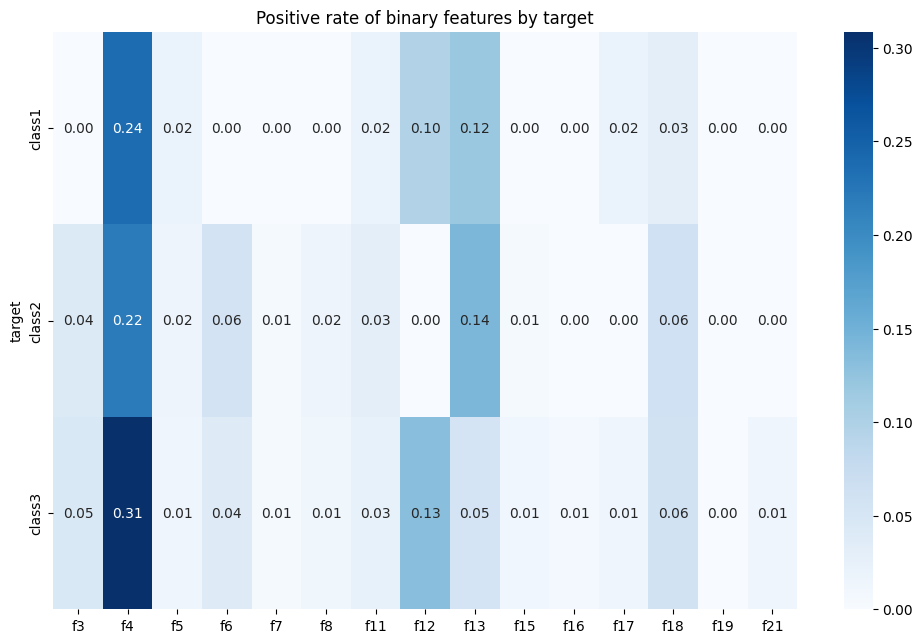

In [103]:
if binary_cols:
    binary_rate_by_target = train.groupby(TARGET_COL)[binary_cols].mean().round(4)
    display(binary_rate_by_target)

    plt.figure(figsize=(12, max(4, len(binary_cols) * 0.5)))
    sns.heatmap(binary_rate_by_target, annot=True, cmap="Blues", fmt=".2f")
    plt.title("Positive rate of binary features by target")
    plt.show()
else:
    print("No binary features detected.")

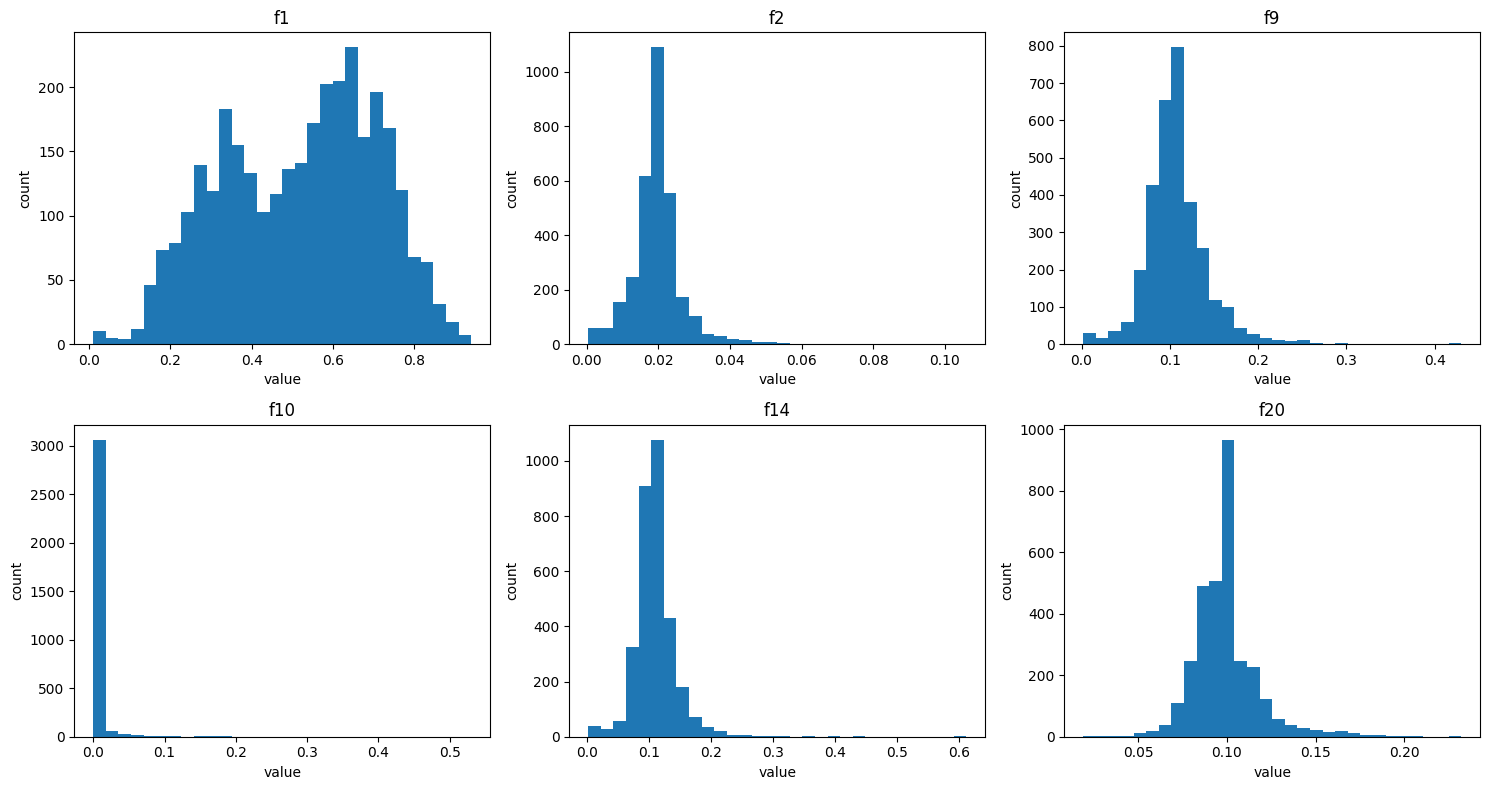

In [104]:
if continuous_cols:
    n_cols = 3
    n_rows = int(np.ceil(len(continuous_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, continuous_cols):
        ax.hist(train[col].dropna(), bins=30)
        ax.set_title(col)
        ax.set_xlabel("value")
        ax.set_ylabel("count")

    for ax in axes[len(continuous_cols):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No continuous features to plot.")

In [105]:
outlier_rows = []
for col in continuous_cols:
    s = train[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (train[col] < lower) | (train[col] > upper)
    outlier_rows.append({
        "feature": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(mask.sum()),
        "outlier_percent": round(mask.mean() * 100, 2),
        "min": train[col].min(),
        "max": train[col].max(),
        "p99": train[col].quantile(0.99)
    })

outlier_report = pd.DataFrame(outlier_rows).sort_values("outlier_percent", ascending=False)
display(outlier_report)

,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percent,min,max,p99
3,f10,0.00054,0.0024,0.00186,-0.00225,0.00519,387,12.09,0.0000,0.5300,0.08909
1,f2,0.01700,0.0230,0.00600,0.00800,0.03200,288,9.00,0.0005,0.1059,0.04690
4,f14,0.09300,0.1220,0.02900,0.04950,0.16550,223,6.97,0.0020,0.6120,0.21700
2,f9,0.08800,0.1220,0.03400,0.03700,0.17300,189,5.91,0.0020,0.4300,0.22501
5,f20,0.08900,0.1070,0.01800,0.06200,0.13400,178,5.56,0.0190,0.2320,0.16700
0,f1,0.36000,0.6700,0.31000,-0.10500,1.13500,0,0.00,0.0100,0.9400,0.87000


In [106]:
outlier_by_target_tables = []
for col in continuous_cols:
    s = train[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    out_mask = ((train[col] < lower) | (train[col] > upper))
    temp = train.assign(is_outlier=out_mask).groupby(TARGET_COL)["is_outlier"].agg(["sum", "mean", "count"])
    temp["feature"] = col
    temp["outlier_rate_percent"] = (temp["mean"] * 100).round(2)
    outlier_by_target_tables.append(temp.reset_index())

if outlier_by_target_tables:
    outliers_by_target = pd.concat(outlier_by_target_tables, ignore_index=True)
    outliers_by_target = outliers_by_target[["feature", TARGET_COL, "sum", "count", "outlier_rate_percent"]]
    display(outliers_by_target.sort_values(["feature", "outlier_rate_percent"], ascending=[True, False]))
else:
    print("No continuous features to analyze.")

,feature,target,sum,count,outlier_rate_percent
0,f1,class1,0,93,0.00
1,f1,class2,0,191,0.00
2,f1,class3,0,2916,0.00
9,f10,class1,93,93,100.00
10,f10,class2,191,191,100.00
11,f10,class3,103,2916,3.53
12,f14,class1,66,93,70.97
14,f14,class3,157,2916,5.38
13,f14,class2,0,191,0.00
3,f2,class1,45,93,48.39


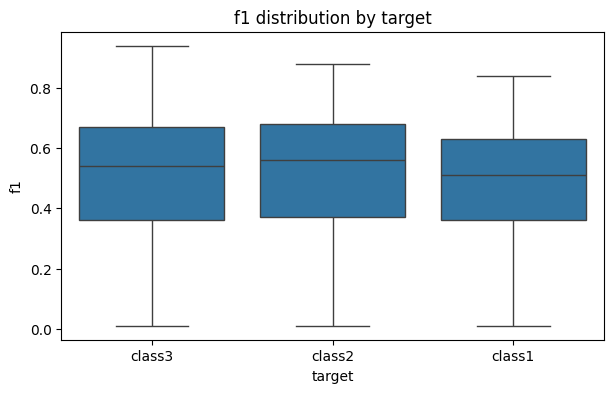

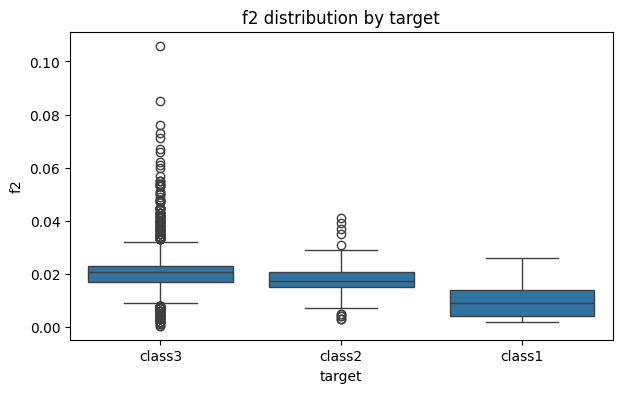

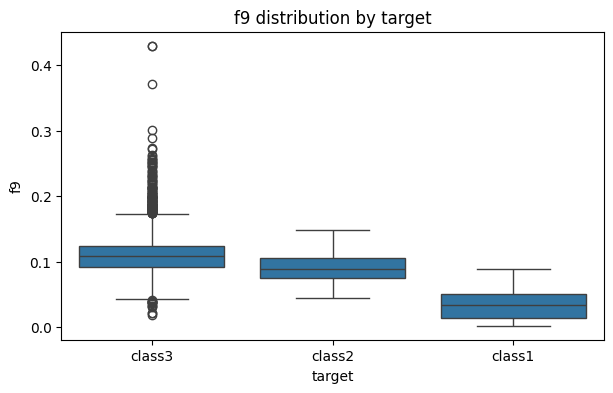

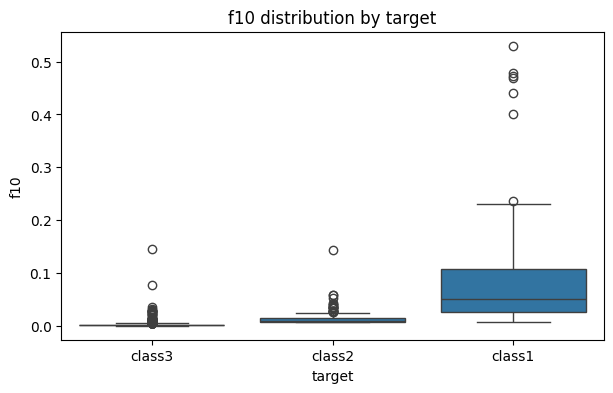

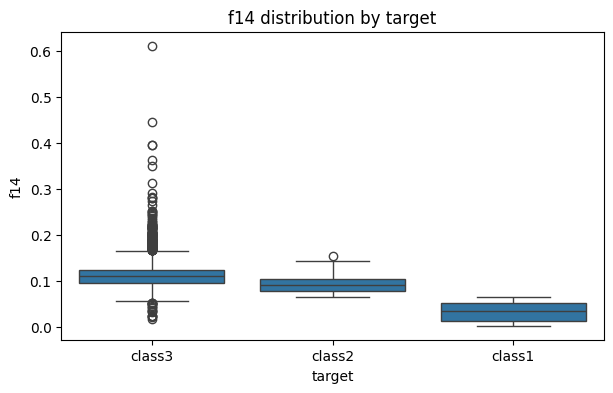

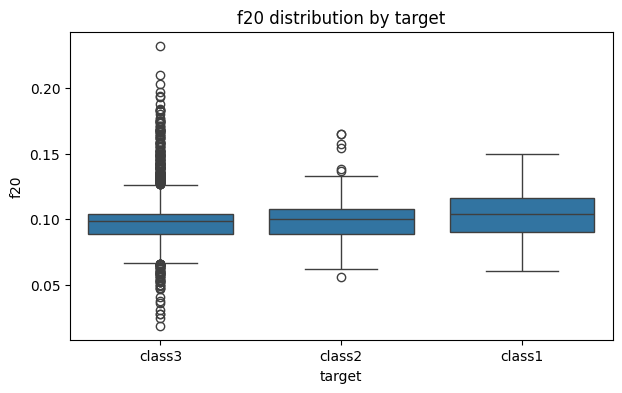

In [107]:
for col in continuous_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=train, x=TARGET_COL, y=col)
    plt.title(f"{col} distribution by target")
    plt.show()

,f1,f2,f9,f10,f14,f20
f1,1.000,-0.231,-0.044,-0.057,0.053,-0.171
f2,-0.231,1.000,0.521,-0.167,0.338,0.383
f9,-0.044,0.521,1.000,-0.272,0.777,0.413
f10,-0.057,-0.167,-0.272,1.000,-0.297,0.078
f14,0.053,0.338,0.777,-0.297,1.000,-0.182
f20,-0.171,0.383,0.413,0.078,-0.182,1.000


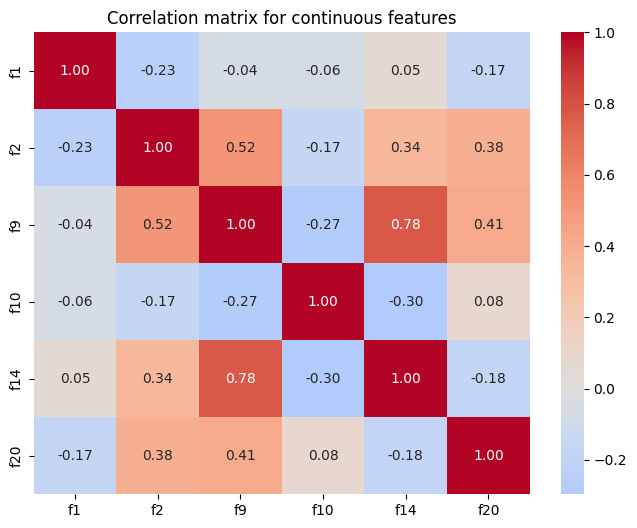

In [108]:
if len(continuous_cols) >= 2:
    corr = train[continuous_cols].corr()
    display(corr.round(3))

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
    plt.title("Correlation matrix for continuous features")
    plt.show()
else:
    print("Not enough continuous features for correlation matrix.")

In [109]:
print("EDA Observations")
print("=" * 60)
print(f"Rows: {len(train)}")
print(f"Features: {len(feature_cols)}")
print(f"Classes: {train[TARGET_COL].nunique()} -> {list(train[TARGET_COL].unique())}")
print("\nTarget distribution:")
print(target_summary)

print("\nMissing values:")
print(f"Total missing in train features: {int(train[feature_cols].isna().sum().sum())}")

print("\nDuplicate feature groups:")
print(f"Duplicate feature rows ignoring ID and target: {duplicate_feature_rows}")
print(f"Conflicting duplicate groups with different target: {len(conflicting_groups)}")

print("\nFeature types:")
print(f"Binary: {binary_cols}")
print(f"Continuous: {continuous_cols}")
print(f"Categorical: {categorical_cols}")

if not outlier_report.empty:
    print("\nTop continuous features by IQR outlier percent:")
    display(outlier_report[["feature", "outlier_count", "outlier_percent", "max", "p99"]].head(10))


EDA Observations
Rows: 3200
Features: 21
Classes: 3 -> ['class3', 'class2', 'class1']

Target distribution:
        count  percent
target                
class3   2916    91.12
class2    191     5.97
class1     93     2.91

Missing values:
Total missing in train features: 0

Duplicate feature groups:
Duplicate feature rows ignoring ID and target: 57
Conflicting duplicate groups with different target: 0

Feature types:
Binary: ['f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f11', 'f12', 'f13', 'f15', 'f16', 'f17', 'f18', 'f19', 'f21']
Continuous: ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']
Categorical: []

Top continuous features by IQR outlier percent:


,feature,outlier_count,outlier_percent,max,p99
3,f10,387,12.09,0.5300,0.08909
1,f2,288,9.00,0.1059,0.04690
4,f14,223,6.97,0.6120,0.21700
2,f9,189,5.91,0.4300,0.22501
5,f20,178,5.56,0.2320,0.16700
0,f1,0,0.00,0.9400,0.87000


# **preproccing**

In [110]:
X = train[feature_cols].copy()
y = train[TARGET_COL].copy()

test_X = None
if test is not None:
    test_X = test[feature_cols].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("test_X shape:", None if test_X is None else test_X.shape)

X shape: (3200, 21)
y shape: (3200,)
test_X shape: (3200, 21)


In [111]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("X_train:", X_train.shape, "X_val:", X_val.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).round(4))
print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True).round(4))

X_train: (2560, 21) X_val: (640, 21)

Train target distribution:
target
class3    0.9113
class2    0.0598
class1    0.0289
Name: proportion, dtype: float64

Validation target distribution:
target
class3    0.9109
class2    0.0594
class1    0.0297
Name: proportion, dtype: float64


In [112]:
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold


groups = pd.util.hash_pandas_object(X, index=False).astype(str)

print("Number of rows:", len(X))
print("Number of unique feature groups:", groups.nunique())
print("Number of duplicated feature groups:", len(X) - groups.nunique())


# cv_regular = StratifiedKFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=SEED
# )

cv_grouped = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

Number of rows: 3200
Number of unique feature groups: 3143
Number of duplicated feature groups: 57


In [113]:
from sklearn import set_config
set_config(transform_output="default")

binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

continuous_tree_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

continuous_standard_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

continuous_robust_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

# categorical_transformer = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("onehot", OneHotEncoder(handle_unknown="ignore"))
# ])


def make_preprocessor(continuous_transformer):
    transformers = []

    if continuous_cols:
        transformers.append(("continuous", continuous_transformer, continuous_cols))

    if binary_cols:
        transformers.append(("binary", binary_transformer, binary_cols))


    return ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )


preprocess_tree = make_preprocessor(continuous_tree_transformer)
preprocess_standard = make_preprocessor(continuous_standard_transformer)
preprocess_robust = make_preprocessor(continuous_robust_transformer)


all_features_standard_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess_all_standard = ColumnTransformer(
    transformers=[
        ("all_features", all_features_standard_transformer, feature_cols)
    ],
    remainder="drop"
)

print("Preprocessors are ready.")

Preprocessors are ready.


# <div dir="rtl" style="text-align:right">

## experiments classification
</div>

In [114]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_val)

print("Dummy Accuracy:", accuracy_score(y_val, dummy_preds))
print("Dummy Macro F1:", f1_score(y_val, dummy_preds, average="macro"))
print("Dummy Weighted F1:", f1_score(y_val, dummy_preds, average="weighted"))
print("\nClassification report:")
print(classification_report(y_val, dummy_preds))

Dummy Accuracy: 0.9109375
Dummy Macro F1: 0.3177977650585991
Dummy Weighted F1: 0.8684817048242028

Classification report:
              precision    recall  f1-score   support

      class1       0.00      0.00      0.00        19
      class2       0.00      0.00      0.00        38
      class3       0.91      1.00      0.95       583

    accuracy                           0.91       640
   macro avg       0.30      0.33      0.32       640
weighted avg       0.83      0.91      0.87       640



In [115]:
from sklearn.model_selection import cross_validate
import numpy as np

def evaluate_cv(model_name, pipeline, X, y, cv, groups=None):
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        groups=groups,
        scoring={
            "accuracy": "accuracy",
            "f1_macro": "f1_macro",
            "f1_weighted": "f1_weighted"
        },
        return_train_score=True,
        n_jobs=-1
    )

    return {
        "model": model_name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_accuracy_std": scores["test_accuracy"].std(),
        "cv_f1_macro_mean": scores["test_f1_macro"].mean(),
        "cv_f1_macro_std": scores["test_f1_macro"].std(),
        "cv_f1_weighted_mean": scores["test_f1_weighted"].mean(),
        "cv_f1_weighted_std": scores["test_f1_weighted"].std(),
        "train_f1_macro_mean": scores["train_f1_macro"].mean()
    }

In [117]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import StratifiedGroupKFold
experiments = []

pipe_rf_original = Pipeline(steps=[
    ("preprocess", preprocess_tree),
    ("model", RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1))
])
experiments.append(("RF_original_like_without_class_weight_n_estimators200", pipe_rf_original, {
    "model_type": "RandomForestClassifier",
    "n_estimators": 200,
    "class_weight": "None",
    "preprocessing": "tree_preprocessing_no_scaling"
}))




pipe_rf_balanced_nEstimators200 = Pipeline(steps=[
    ("preprocess", preprocess_tree),
    ("model", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=SEED, n_jobs=-1))
])
experiments.append(("RF_balanced_n_estimators200", pipe_rf_balanced_nEstimators200, {
    "model_type": "RandomForestClassifier",
    "n_estimators": 200,
    "class_weight": "balanced",
    "preprocessing": "tree_preprocessing_no_scaling"
}))



pipe_rf_balanced_nEstimators100 = Pipeline(steps=[
    ("preprocess", preprocess_tree),
    ("model", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=SEED, n_jobs=-1))
])
experiments.append(("RF_balanced_n_estimators100", pipe_rf_balanced_nEstimators100, {
    "model_type": "RandomForestClassifier",
    "n_estimators": 100,
    "class_weight": "balanced",
    "preprocessing": "tree_preprocessing_no_scaling"
}))


pipe_rf_leaf2 = Pipeline(steps=[
    ("preprocess", preprocess_tree),
    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        max_features="sqrt",
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1
    ))
])
experiments.append(("RF_200_balanced_leaf2_sqrt", pipe_rf_leaf2, {
    "model_type": "RandomForestClassifier",
    "n_estimators": 200,
    "class_weight": "balanced",
    "max_features": "sqrt",
    "min_samples_leaf": 2,
    "preprocessing": "tree_preprocessing_no_scaling"
}))




pipe_rf_balanced_subsample_100 = Pipeline(steps=[
    ("preprocess", preprocess_tree),
    ("model", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1
    ))
])
experiments.append(("RF_100_balanced_subsample", pipe_rf_balanced_subsample_100, {
    "model_type": "RandomForestClassifier",
    "n_estimators": 100,
    "class_weight": "balanced_subsample",
    "preprocessing": "tree_preprocessing_no_scaling"
}))



# _________________________________________________________________________

pipe_logreg_balanced = Pipeline(steps=[
    ("preprocess", preprocess_standard),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED))
])
experiments.append(("LogReg_standard_balanced", pipe_logreg_balanced, {
    "model_type": "LogisticRegression",
    "max_iter": 3000,
    "class_weight": "balanced",
    "preprocessing": "median_impute_standard_scaler_for_continuous"
}))
pipe_logreg_balanced = Pipeline(steps=[
    ("preprocess", preprocess_robust),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED))
])
experiments.append(("LogReg_robust_balanced", pipe_logreg_balanced, {
    "model_type": "LogisticRegression",
    "max_iter": 3000,
    "class_weight": "balanced",
    "preprocessing": "median_impute_robust_scaler_for_continuous"
}))
# # ________________________________________________________________________________________________




# for C in [0.03, 0.1, 0.3, 1.0]:
pipe_poly_logreg = Pipeline(steps=[
    ("preprocess", preprocess_all_standard),
    ("poly", PolynomialFeatures(
        degree=2,
        include_bias=False
    )),
    ("model", LogisticRegression(
        C=1.0,
        penalty="l2",
        solver="lbfgs",
        max_iter=5000,
        class_weight="balanced",
        random_state=SEED
    ))
])
name = f"Poly2_LogReg_C1.0"
experiments.append((name, pipe_poly_logreg, {
    "model_type": "PolynomialFeatures + LogisticRegression",
    "degree": 2,
    "C": 1.0,
    "penalty": "l2",
    "class_weight": "balanced",
    "preprocessing": "standard_scaler_all_features"
}))


def get_cv(seed):
    return StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

# @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
SEEDS = [42, 123, 2024, 777, 999]

all_results = []

for name, pipe, params in experiments:
    print(f"\nModel: {name}")

    seed_val_scores = []
    seed_train_scores = []

    for seed in SEEDS:
        cv = get_cv(seed)

        result = evaluate_cv(
            model_name=f"{name}_seed{seed}",
            pipeline=pipe,
            X=X,
            y=y,
            cv=cv,
            groups=groups
        )

        seed_val_scores.append(result["cv_f1_macro_mean"])
        seed_train_scores.append(result["train_f1_macro_mean"])

    val_mean = np.mean(seed_val_scores)
    val_std = np.std(seed_val_scores, ddof=1)
    train_mean = np.mean(seed_train_scores)
    all_results.append({
        "model": name,
        "mean_cv_over_seeds": val_mean,
        "std_cv_over_seeds": val_std,
        "worst_seed_cv": np.min(seed_val_scores),
        "train_cv_over_seeds": train_mean,
        "generalization_gap": train_mean - val_mean,
        "stability_score": val_mean - val_std,
        "all_seed_val_scores": seed_val_scores,
        "all_seed_train_scores": seed_train_scores,
    })

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(
    by=[
        "stability_score",
        "worst_seed_cv",
        "mean_cv_over_seeds"
    ],
    ascending=False
).reset_index(drop=True)

display(results_df)


Model: RF_original_like_without_class_weight_n_estimators200

Model: RF_balanced_n_estimators200

Model: RF_balanced_n_estimators100

Model: RF_200_balanced_leaf2_sqrt

Model: RF_100_balanced_subsample

Model: LogReg_standard_balanced

Model: LogReg_robust_balanced

Model: Poly2_LogReg_C1.0


,model,mean_cv_over_seeds,std_cv_over_seeds,worst_seed_cv,train_cv_over_seeds,generalization_gap,stability_score,all_seed_val_scores,all_seed_train_scores
0,RF_100_balanced_subsample,0.985396,0.002733,0.983218,1.000000,0.014604,0.982663,"[0.9832178177499238, 0.9835727878811437, 0.986...","[1.0, 1.0, 1.0, 1.0, 1.0]"
1,RF_balanced_n_estimators100,0.984989,0.003117,0.980706,1.000000,0.015011,0.981872,"[0.9847941038695536, 0.9836320240217873, 0.987...","[1.0, 1.0, 1.0, 1.0, 1.0]"
2,RF_balanced_n_estimators200,0.984328,0.002607,0.980706,1.000000,0.015672,0.981721,"[0.9847941038695536, 0.9836320240217873, 0.984...","[1.0, 1.0, 1.0, 1.0, 1.0]"
3,RF_original_like_without_class_weight_n_estima...,0.978970,0.002178,0.976441,1.000000,0.021030,0.976792,"[0.9779321075113321, 0.981612868803186, 0.9808...","[1.0, 1.0, 1.0, 1.0, 1.0]"
4,RF_200_balanced_leaf2_sqrt,0.978832,0.002149,0.975259,0.990127,0.011295,0.976684,"[0.9752590632712053, 0.9786922240764216, 0.980...","[0.9883685193722094, 0.9906496451523085, 0.991..."
5,LogReg_robust_balanced,0.906222,0.002948,0.903024,0.921866,0.015644,0.903274,"[0.9079432202114216, 0.9032786342808027, 0.903...","[0.9231641604884004, 0.9227114574918318, 0.920..."
6,LogReg_standard_balanced,0.897726,0.002103,0.895699,0.915096,0.017370,0.895623,"[0.9006320978715798, 0.8966132410975121, 0.896...","[0.9153132922171409, 0.9163593697961148, 0.912..."
7,Poly2_LogReg_C1.0,0.863264,0.012263,0.845460,0.959574,0.096310,0.851001,"[0.8622390665248043, 0.8718707242326251, 0.845...","[0.9593232917152958, 0.960654395350917, 0.9585..."


In [118]:
import tempfile
import os
import joblib
import mlflow
import numpy as np
from mlflow.models.signature import infer_signature

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("fite-classification-final")


for name, pipe, params in experiments:

    print("Logging:", name)
    matched_rows = results_df[results_df["model"] == name]
    if matched_rows.empty:
        print(f" Skipping {name}: no matching row found in results_df")
        continue

    result_row = matched_rows.iloc[0]

    with mlflow.start_run(run_name=name):

        mlflow.log_params(params)
        mlflow.log_param("n_seeds", len(SEEDS))
        mlflow.log_param("seeds", str(SEEDS))
        mlflow.log_param("n_features", len(feature_cols))
        mlflow.log_param("n_classes", y.nunique())
        mlflow.log_param("binary_cols", ",".join(map(str, binary_cols)))
        mlflow.log_param("continuous_cols", ",".join(map(str, continuous_cols)))

        if "categorical_cols" in globals():
            mlflow.log_param("categorical_cols", ",".join(map(str, categorical_cols)))
        else:
            mlflow.log_param("categorical_cols", "")

        mlflow.log_metric("cv_f1_macro_mean", float(result_row["mean_cv_over_seeds"]))
        mlflow.log_metric("cv_f1_macro_std", float(result_row["std_cv_over_seeds"]))
        mlflow.log_metric("cv_f1_macro_worst_seed", float(result_row["worst_seed_cv"]))

        mlflow.log_metric("train_f1_macro_mean", float(result_row["train_cv_over_seeds"]))
        mlflow.log_metric("generalization_gap", float(result_row["generalization_gap"]))
        mlflow.log_metric("stability_score", float(result_row["stability_score"]))


        for i, score in enumerate(result_row["all_seed_val_scores"]):
            mlflow.log_metric(f"cv_val_seed_{i}", float(score))

        for i, score in enumerate(result_row["all_seed_train_scores"]):
            mlflow.log_metric(f"cv_train_seed_{i}", float(score))


        pipe.fit(X, y)
        input_example = X.head(5)
        signature = infer_signature(input_example, pipe.predict(input_example))

        try:
            mlflow.sklearn.log_model(
                sk_model=pipe,
                artifact_path="model_pipeline",
                serialization_format="cloudpickle",
                input_example=input_example,
                signature=signature
            )

        except Exception as e:
            print("MLflow sklearn failed → fallback joblib")
            print(e)

            with tempfile.TemporaryDirectory() as tmpdir:
                model_path = os.path.join(tmpdir, "model.joblib")
                joblib.dump(pipe, model_path)
                mlflow.log_artifact(model_path, artifact_path="model_joblib")

print(" MLflow logging completed")

Logging: RF_original_like_without_class_weight_n_estimators200


2026/07/01 16:17:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/01 16:17:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logging: RF_balanced_n_estimators200


2026/07/01 16:17:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/01 16:17:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logging: RF_balanced_n_estimators100


...

Logging: LogReg_robust_balanced


2026/07/01 16:17:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/01 16:17:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logging: Poly2_LogReg_C1.0


2026/07/01 16:18:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/01 16:18:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


 MLflow logging completed


In [119]:
best_model_name = results_df.iloc[0]["model"]
print("Best model by CV macro F1:", best_model_name)

best_pipeline = None
for name, pipe, params in experiments:
    if name == best_model_name:
        best_pipeline = pipe
        best_params = params
        break

best_pipeline.fit(X, y)
print("Best pipeline fitted on full training data.")
print("Best params:", best_params)

Best model by CV macro F1: RF_100_balanced_subsample
Best pipeline fitted on full training data.
Best params: {'model_type': 'RandomForestClassifier', 'n_estimators': 100, 'class_weight': 'balanced_subsample', 'preprocessing': 'tree_preprocessing_no_scaling'}


In [120]:
if test is not None:
    test_predictions = best_pipeline.predict(test_X)
    submission = pd.DataFrame({
        ID_COL: test[ID_COL],
        TARGET_COL: test_predictions
    })

    display(submission.head())
    print("Submission shape:", submission.shape)
    print("Columns:", list(submission.columns))
    print("Predicted target distribution:")
    print(submission[TARGET_COL].value_counts(normalize=True).round(4))

    output_path =  f"submission_{best_model_name}.csv"
    submission.to_csv(output_path, index=False)
    print("Saved submission to:", output_path)
else:
    print("test_data.csv not found. Submission file was not created.")

,ID,target
0,10000,class3
1,10001,class3
2,10002,class3
3,10003,class3
4,10004,class3


Submission shape: (3200, 2)
Columns: ['ID', 'target']
Predicted target distribution:
target
class3    0.9153
class2    0.0591
class1    0.0256
Name: proportion, dtype: float64
Saved submission to: submission_RF_100_balanced_subsample.csv


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!mlflow ui

Backend store URI not provided. Using sqlite:///mlflow.db
Registry store URI not provided. Using backend store URI.
[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
/usr/local/lib/python3.12/dist-packages/mlflow/server/fastapi_app.py:17: StarletteDeprecationWarning: starlette.middleware.wsgi is deprecated and will be removed in a future release. Please refer to https://github.com/abersheeran/a2wsgi as a replacement.
  from starlette.middleware.wsgi import WSGIResponder, build_environ
2026/07/01 16:18:32 INFO:     Uvicorn running on http://127.0.0.1:5000 (Press CTRL+C to quit)
2026/07/01 16:18:32 INFO:     Started parent process [86881]
Traceback (most recent call last):
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dis